# Phase 1: Bio-Optic Sensor Calibration (Dataset 1)

A hospital has procured a new batch of low-cost, non-invasive optical biosensors designed to
measure peripheral blood oxygenation. However, the raw voltage output from the sensor needs
to be calibrated against a highly accurate (but expensive and invasive) arterial blood gas test.
While the theoretical relationship between the raw voltage and the true blood oxygen level is
linear, these low-cost sensors are inherently noisy due to ambient light interference. This dataset
serves as your pipeline’s foundational sanity check.

1. Gradient Descent vs. Closed Form: Implement Ordinary Least Squares (OLS) using
both the closed-form normal equations and vectorized batch gradient descent. Train both
on Dataset 1. Report the L2 norm of the difference between the final weight vectors
produced by both methods.

2. Primal to Dual Translation: Convert Dataset 1 into a binary classification problem
by thresholding the target variable at its median. Formulate the hard-margin SVM dual
optimization problem. Use scipy.optimize.minimize to solve for the Lagrange multi-
pliers (μ). Extract and print the exact indices of the support vectors from the training
set.

https://docs.scipy.org/doc/scipy/tutorial/index.html#user-guide

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset = np.genfromtxt("../PRNN_2026_A1_data/dataset_1.csv", delimiter=",", dtype=float, skip_header=1, filling_values=np.nan)

In [3]:
dataset.shape

(5000, 2)

In [4]:
np.isnan(dataset).any()

np.False_

In [5]:
x = dataset[:, 0]
y = dataset[:, 1]

print(x.shape, y.shape)

(5000,) (5000,)


## 1.1 Gradient Descent vs. Closed Form:

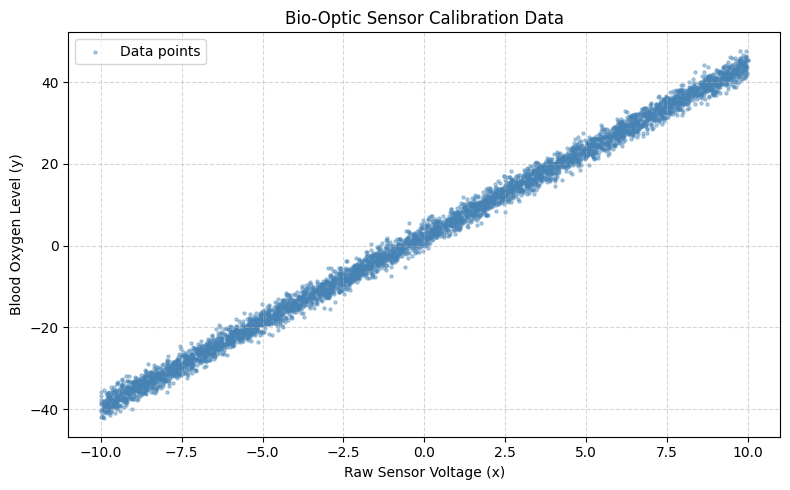

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=5, alpha=0.4, color='steelblue', label='Data points')
plt.xlabel('Raw Sensor Voltage (x)')
plt.ylabel('Blood Oxygen Level (y)')
plt.title('Bio-Optic Sensor Calibration Data')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Closed-Form Solution:

In [7]:
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

ones = np.ones((x.shape[0], 1))
X = np.concatenate((ones, x), axis=1)

In [8]:
X.shape, y.shape

((5000, 2), (5000, 1))

In [9]:
def solve_ols(X, Y):
    return np.linalg.inv(X.T @ X) @ X.T @ Y

In [10]:
w = solve_ols(X, y)

/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_67438/3561543689.py:2: RuntimeWarning: divide by zero encountered in matmul
  return np.linalg.inv(X.T @ X) @ X.T @ Y
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_67438/3561543689.py:2: RuntimeWarning: overflow encountered in matmul
  return np.linalg.inv(X.T @ X) @ X.T @ Y
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_67438/3561543689.py:2: RuntimeWarning: invalid value encountered in matmul
  return np.linalg.inv(X.T @ X) @ X.T @ Y


In [11]:
w

array([[2.47190022],
       [4.19290149]])

In [13]:
def solve_ols2(X, Y):
    return np.linalg.solve(X.T @ X, X.T @ Y)

w = solve_ols2(X, y)

In [14]:
w

array([[2.47190022],
       [4.19290149]])

### GD Solution: